In [1]:
# https://docs.jaxstack.ai/en/latest/neural_net_basics.html

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()

print(f"{digits.data.shape=}")
print(f"{digits.target.shape=}")

digits.data.shape=(1797, 64)
digits.target.shape=(1797,)


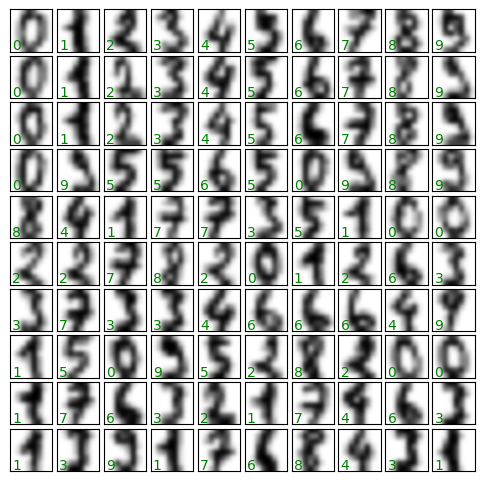

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(6, 6),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='gaussian')
    ax.text(0.05, 0.05, str(digits.target[i]), transform=ax.transAxes, color='green')

In [6]:
from sklearn.model_selection import train_test_split
splits = train_test_split(digits.images, digits.target, random_state=0)


In [7]:
import jax.numpy as jnp
images_train, images_test, label_train, label_test = map(jnp.asarray, splits)
print(f"{images_train.shape=} {label_train.shape=}")
print(f"{images_test.shape=}  {label_test.shape=}")

images_train.shape=(1347, 8, 8) label_train.shape=(1347,)
images_test.shape=(450, 8, 8)  label_test.shape=(450,)


In [11]:
from flax import nnx
class SimpleNN(nnx.Module):
    def __init__(self, n_feats: int=64, n_hidden: int=100, n_targets: int=10, *, rngs: nnx.Rngs):
        self.n_feats = n_feats
        self.layer1 = nnx.Linear(n_feats, n_hidden, rngs=rngs)
        self.layer2 = nnx.Linear(n_hidden, n_hidden, rngs=rngs)
        self.layer3 = nnx.Linear(n_hidden, n_targets, rngs=rngs)
    def __call__(self, x):
        x = x.reshape(x.shape[0], self.n_feats)
        x = nnx.selu(self.layer1(x))
        x = nnx.selu(self.layer2(x))
        x = self.layer3(x)
        return x

model = SimpleNN(rngs=nnx.Rngs(0))

nnx.display(model)  # Interactive display if penzai is installed.

In [12]:
import jax
import optax

optimizer = nnx.ModelAndOptimizer(model, optax.sgd(learning_rate=0.05))

def loss_fun(
    model: nnx.Module,
    data: jax.Array,
    labels: jax.Array):
  logits = model(data)
  loss = optax.softmax_cross_entropy_with_integer_labels(
    logits=logits, labels=labels
  ).mean()
  return loss, logits

@nnx.jit  # JIT-compile the function
def train_step(
    model: nnx.Module,
    optimizer: nnx.Optimizer,
    data: jax.Array,
    labels: jax.Array):
  loss_gradient = nnx.grad(loss_fun, has_aux=True)  # gradient transform!
  grads, logits = loss_gradient(model, data, labels)
  optimizer.update(grads)  # inplace update

In [13]:
for i in range(301):  # 300 training epochs
  train_step(model, optimizer, images_train, label_train)
  if i % 50 == 0:  # Print metrics.
    loss, _ = loss_fun(model, images_test, label_test)
    print(f"epoch {i}: loss={loss:.2f}")

epoch 0: loss=20.19
epoch 50: loss=0.20
epoch 100: loss=0.14
epoch 150: loss=0.12
epoch 200: loss=0.11
epoch 250: loss=0.11
epoch 300: loss=0.11


In [14]:
label_pred = model(images_test).argmax(axis=1)
num_matches = jnp.count_nonzero(label_pred == label_test)
num_total = len(label_test)
accuracy = num_matches / num_total
print(f"{num_matches} labels match out of {num_total}:"
      f" accuracy = {num_matches/num_total:%}")

436 labels match out of 450: accuracy = 96.888894%


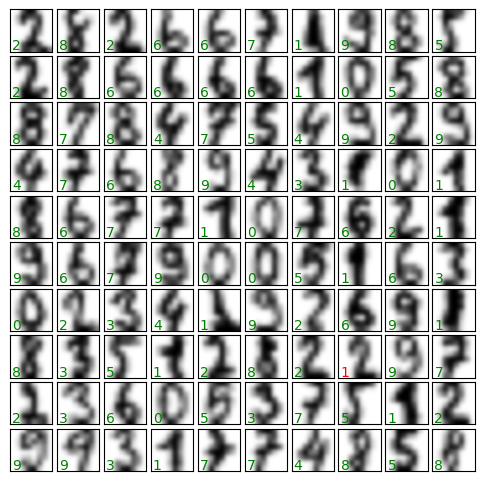

In [15]:
fig, axes = plt.subplots(10, 10, figsize=(6, 6),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(images_test[i], cmap='binary', interpolation='gaussian')
    color = 'green' if label_pred[i] == label_test[i] else 'red'
    ax.text(0.05, 0.05, str(label_pred[i]), transform=ax.transAxes, color=color)